In [ ]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

class HeatPINN(nn.Module):  # Same for both PINN & RoPINN
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2, 50), nn.Tanh(),
            nn.Linear(50, 50), nn.Tanh(),
            nn.Linear(50, 1)
        )
    def forward(self, xt):
        return self.net(xt)

print("Model ready!")

Model ready!


In [ ]:
alpha = 0.01  # Diffusion coefficient

def heat_residual(model, x, t):
    x = x.clone().requires_grad_(True)
    t = t.clone().requires_grad_(True)
    xt = torch.cat([x, t], dim=1)
    u = model(xt)
    u_t = torch.autograd.grad(u, t, grad_outputs=torch.ones_like(u), create_graph=True)[0]
    u_xx = torch.autograd.grad(torch.autograd.grad(u, x, grad_outputs=torch.ones_like(u), create_graph=True)[0], x, grad_outputs=torch.ones_like(u), create_graph=True)[0]
    f = u_t - alpha * u_xx
    return f

# IC: Gaussian bump at t=0
def ic_residual(model, x_ic):
    t_ic = torch.zeros_like(x_ic)
    xt_ic = torch.cat([x_ic, t_ic], dim=1)
    u_ic = model(xt_ic)
    u_exact_ic = torch.exp(-x_ic**2)  # Hot in middle
    return u_ic - u_exact_ic

# BC: u(±1,t)=0
def bc_residual(model, t_bc):
    x_left = -torch.ones_like(t_bc)
    x_right = torch.ones_like(t_bc)
    xt_left = torch.cat([x_left, t_bc], dim=1)
    xt_right = torch.cat([x_right, t_bc], dim=1)
    return torch.cat([model(xt_left), model(xt_right)])

print("Heat equation ready!")

Heat equation ready!


In [ ]:
model_pinn = HeatPINN()
opt_pinn = torch.optim.Adam(model_pinn.parameters(), lr=0.001)

N = 50
x_col = torch.linspace(-1,1,N).unsqueeze(1)
t_col = torch.linspace(0,1,N).unsqueeze(1)
x_ic = torch.linspace(-1,1,N).unsqueeze(1)
t_bc = torch.linspace(0,1,N).unsqueeze(1)

for e in range(1000):  # More epochs for convergence
    opt_pinn.zero_grad()
    f = heat_residual(model_pinn, x_col, t_col)
    ic = ic_residual(model_pinn, x_ic)
    bc = bc_residual(model_pinn, t_bc)
    loss = torch.mean(f**2) + torch.mean(ic**2) + torch.mean(bc**2)
    loss.backward()
    opt_pinn.step()
    if e % 200 == 0: print(f"PINN Epoch {e}, Loss: {loss.item():.4f}")

print("PINN done!")

PINN Epoch 0, Loss: 0.7611
PINN Epoch 200, Loss: 0.0218
PINN Epoch 400, Loss: 0.0150
PINN Epoch 600, Loss: 0.0124
PINN Epoch 800, Loss: 0.0107
PINN done!


In [ ]:
# Simple region sample (Gaussian around center)
def region_sample(N=50):
    mean = torch.zeros(2)
    cov = torch.eye(2) * 0.1
    samples = torch.distributions.MultivariateNormal(mean, cov).sample((N,))
    samples = torch.clamp(samples, -1, 1)
    return samples[:,0].unsqueeze(1), samples[:,1].unsqueeze(1)

model_ropinn = HeatPINN()
opt_ropinn = torch.optim.Adam(model_ropinn.parameters(), lr=0.001)

for e in range(1000):
    opt_ropinn.zero_grad()
    x_r, t_r = region_sample(N)
    f = heat_residual(model_ropinn, x_r, t_r)
    ic = ic_residual(model_ropinn, x_ic)
    bc = bc_residual(model_ropinn, t_bc)
    loss = torch.mean(f**2) + torch.mean(ic**2) + torch.mean(bc**2)
    loss.backward()
    opt_ropinn.step()
    if e % 200 == 0: print(f"RoPINN Epoch {e}, Loss: {loss.item():.4f}")

print("RoPINN done!")

RoPINN Epoch 0, Loss: 0.5232
RoPINN Epoch 200, Loss: 0.0235
RoPINN Epoch 400, Loss: 0.0171
RoPINN Epoch 600, Loss: 0.0150
RoPINN Epoch 800, Loss: 0.0109
RoPINN done!


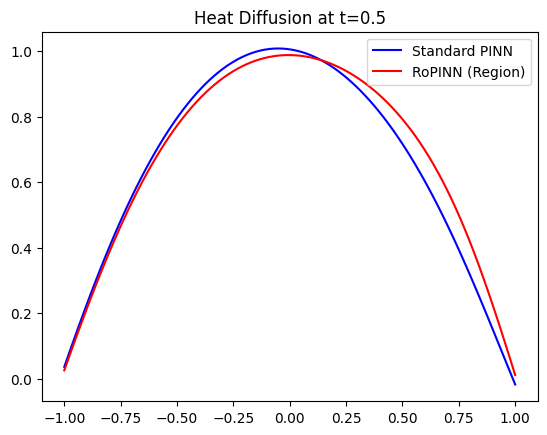

In [ ]:
x_test = torch.linspace(-1,1,100).unsqueeze(1)
t_test = 0.5 * torch.ones_like(x_test)
xt_test = torch.cat([x_test, t_test], dim=1)

u_pinn = model_pinn(xt_test).detach().numpy()
u_ropinn = model_ropinn(xt_test).detach().numpy()

plt.plot(x_test, u_pinn, 'b-', label='Standard PINN')
plt.plot(x_test, u_ropinn, 'r-', label='RoPINN (Region)')
plt.title('Heat Diffusion at t=0.5')
plt.legend()
plt.show()